# Modeling — ADFA-LD

**Phase 2 du PLAN.md** — Prototype complet du pipeline.

On enchaîne en une seule passe :
1. **Charger** les 5 951 fichiers (réutilise la logique du notebook EDA)
2. **Nettoyer** (rejets : `length < 10`, tokens non-entiers)
3. **Splitter** train/test en GROUPANT par scénario (anti-leakage)
4. **Vectoriser** en trigrammes (`CountVectorizer`, max 500 features)
5. **Entraîner** Random Forest balanced + calibration isotonic
6. **Cross-valider** sur train (5-fold)
7. **Évaluer** sur test (UNE seule fois)
8. **Vérifier** la checklist anti-overfitting

Tous les artefacts (modèle, métriques, figures) sont sauvegardés sous `saved_models/` et `results/`.

## 0. Setup

In [1]:
import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE = Path("../data/ADFA-LD")
TRAINING = BASE / "Training_Data_Master"
VALIDATION = BASE / "Validation_Data_Master"
ATTACK = BASE / "Attack_Data_Master"

RESULTS = Path("../results/modeling")
RESULTS.mkdir(parents=True, exist_ok=True)
MODELS = Path("../saved_models")
MODELS.mkdir(parents=True, exist_ok=True)

print("OK — chemins prêts")

OK — chemins prêts


## 1. Chargement

On reprend la même fonction qu'au notebook EDA. Chaque ligne = un fichier, avec son label, sa famille et son scénario (groupe pour le split).

In [2]:
def load_syscall_file(path):
    try:
        text = Path(path).read_text(encoding="utf-8", errors="ignore").strip()
    except Exception:
        return "", 0, False
    if not text:
        return "", 0, True
    tokens = text.split()
    valid = all(t.isdigit() for t in tokens)
    return " ".join(tokens), len(tokens), valid


rows = []
for path in sorted(TRAINING.glob("*.txt")):
    seq, length, valid = load_syscall_file(path)
    rows.append({
        "filename": path.name, "label": 0, "family": "normal",
        "scenario": f"normal_{path.stem}",
        "sequence": seq, "length": length, "valid": valid,
    })
for path in sorted(VALIDATION.glob("*.txt")):
    seq, length, valid = load_syscall_file(path)
    rows.append({
        "filename": path.name, "label": 0, "family": "normal",
        "scenario": f"normal_{path.stem}",
        "sequence": seq, "length": length, "valid": valid,
    })
for scenario_dir in sorted(ATTACK.iterdir()):
    if not scenario_dir.is_dir():
        continue
    scenario_name = scenario_dir.name
    family = re.sub(r"_\d+$", "", scenario_name)
    for path in sorted(scenario_dir.glob("*.txt")):
        seq, length, valid = load_syscall_file(path)
        rows.append({
            "filename": path.name, "label": 1, "family": family,
            "scenario": scenario_name,
            "sequence": seq, "length": length, "valid": valid,
        })

df = pd.DataFrame(rows)
print(f"Fichiers chargés : {len(df)}")
print(df["label"].value_counts().rename({0: "Normal", 1: "Attaque"}))

Fichiers chargés : 5951
label
Normal     5205
Attaque     746
Name: count, dtype: int64


## 2. Nettoyage

Règles décidées en Phase 1 (EDA) :
- `length >= 10` syscalls (minimum pour former des trigrammes utiles)
- tous les tokens doivent être des entiers

In [3]:
before = len(df)
df = df[(df.length >= 10) & df.valid].reset_index(drop=True)
after = len(df)
print(f"Avant nettoyage : {before}")
print(f"Après nettoyage : {after}  ({before - after} rejetés)")
print(df["label"].value_counts().rename({0: "Normal", 1: "Attaque"}))

Avant nettoyage : 5951
Après nettoyage : 5951  (0 rejetés)
label
Normal     5205
Attaque     746
Name: count, dtype: int64


## 3. Split — GROUPÉ par scénario (anti-leakage)

**Stratégie clé** : chaque fichier normal a son propre `scenario` (= son `normal_<filename>`), donc le split aléatoire les sépare normalement. Mais tous les fichiers d'un même scénario d'attaque (ex: `Adduser_1`) restent **du même côté** du split — on évite ainsi que le modèle apprenne par cœur une signature d'attaque vue en train.

Vérification croisée : aucun scénario ne doit apparaître à la fois en train et en test.

In [4]:
X_text = df["sequence"].values
y = df["label"].values
groups = df["scenario"].values

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X_text, y, groups=groups))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_train_text = df_train["sequence"].values
X_test_text = df_test["sequence"].values
y_train = df_train["label"].values
y_test = df_test["label"].values
groups_train = df_train["scenario"].values

print(f"Train : {len(df_train)} fichiers — normaux={(y_train==0).sum()}, attaques={(y_train==1).sum()}")
print(f"Test  : {len(df_test)}  fichiers — normaux={(y_test==0).sum()}, attaques={(y_test==1).sum()}")

# Vérification anti-leakage
train_scenarios = set(df_train["scenario"])
test_scenarios = set(df_test["scenario"])
overlap = train_scenarios & test_scenarios
print(f"\nScénarios train : {len(train_scenarios)}")
print(f"Scénarios test  : {len(test_scenarios)}")
print(f"Overlap (doit être 0) : {len(overlap)}")
assert len(overlap) == 0, "LEAKAGE détecté !"

# Répartition des familles d'attaque entre train et test
print("\nFamilles d'attaque — train :")
print(df_train[df_train.label == 1]["family"].value_counts())
print("\nFamilles d'attaque — test :")
print(df_test[df_test.label == 1]["family"].value_counts())

Train : 4154 fichiers — normaux=3641, attaques=513
Test  : 1797  fichiers — normaux=1564, attaques=233

Scénarios train : 3685
Scénarios test  : 1580
Overlap (doit être 0) : 0

Familles d'attaque — train :
family
Web_Shell           102
Hydra_FTP            95
Java_Meterpreter     89
Hydra_SSH            87
Adduser              84
Meterpreter          56
Name: count, dtype: int64

Familles d'attaque — test :
family
Hydra_SSH           89
Hydra_FTP           67
Java_Meterpreter    35
Meterpreter         19
Web_Shell           16
Adduser              7
Name: count, dtype: int64


## 4. Vectorisation — Trigrammes de syscalls

`CountVectorizer` avec `ngram_range=(3,3)`. On limite à 500 trigrammes les plus fréquents (sparse-friendly, évite la malédiction de la dimension). `min_df=2` filtre les trigrammes rares (bruit).

⚠️ **Fit sur train uniquement.** Transform sur test.

In [5]:
vectorizer = CountVectorizer(
    analyzer="word",
    ngram_range=(3, 3),
    max_features=500,
    min_df=2,
    token_pattern=r"\d+",
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Nb features (trigrammes) : {len(vectorizer.get_feature_names_out())}")
print(f"Sparsité X_train : {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.3f}")

X_train shape : (4154, 500)
X_test  shape : (1797, 500)
Nb features (trigrammes) : 500
Sparsité X_train : 0.898


## 5. Cross-validation 5-fold sur train

On utilise `GroupKFold` pour que les folds restent GROUPÉS par scénario, comme le split principal. Sans ça la CV elle-même fuiterait.

Le score CV nous donne une **estimation honnête** de la performance attendue — si l'écart avec le test final est trop grand (> 0.10), c'est un signe d'overfitting.

In [6]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gkf = GroupKFold(n_splits=5)
cv_f1 = cross_val_score(rf_base, X_train, y_train, groups=groups_train, cv=gkf, scoring="f1", n_jobs=-1)
cv_auc = cross_val_score(rf_base, X_train, y_train, groups=groups_train, cv=gkf, scoring="roc_auc", n_jobs=-1)

print("CV 5-fold (GroupKFold) sur train :")
print(f"  F1  : mean={cv_f1.mean():.4f}  std={cv_f1.std():.4f}  folds={np.round(cv_f1, 4).tolist()}")
print(f"  AUC : mean={cv_auc.mean():.4f}  std={cv_auc.std():.4f}  folds={np.round(cv_auc, 4).tolist()}")

CV 5-fold (GroupKFold) sur train :
  F1  : mean=0.7464  std=0.0267  folds=[0.7027, 0.7478, 0.7791, 0.7348, 0.7673]
  AUC : mean=0.9791  std=0.0062  folds=[0.9739, 0.9695, 0.9843, 0.9835, 0.9845]


## 6. Entraînement final : RF + calibration isotonic

La calibration `CalibratedClassifierCV` transforme les scores bruts du RF en probabilités fiables (utile pour fixer un seuil de décision plus tard). On la fit sur train uniquement (cv=5 interne).

In [7]:
model = CalibratedClassifierCV(rf_base, method="isotonic", cv=5)
model.fit(X_train, y_train)
print("Modèle entraîné.")

Modèle entraîné.


## 7. Évaluation sur test (une seule fois)

Métriques principales : **F1, AUC, precision, recall**. On regarde aussi la matrice de confusion et le score par famille d'attaque.

In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

f1_test = f1_score(y_test, y_pred)
auc_test = roc_auc_score(y_test, y_proba)
precision_test = precision_score(y_test, y_pred)
recall_test = recall_score(y_test, y_pred)

print("=== MÉTRIQUES TEST ===")
print(f"F1        : {f1_test:.4f}")
print(f"AUC       : {auc_test:.4f}")
print(f"Precision : {precision_test:.4f}")
print(f"Recall    : {recall_test:.4f}")

gap = abs(cv_f1.mean() - f1_test)
print(f"\nGap CV F1 ↔ Test F1 : {gap:.4f}  (cible < 0.10)")

print("\n--- Classification report ---")
report_txt = classification_report(y_test, y_pred, target_names=["Normal", "Attaque"], digits=4)
print(report_txt)

(RESULTS / "classification_report.txt").write_text(report_txt, encoding="utf-8")

=== MÉTRIQUES TEST ===
F1        : 0.8186
AUC       : 0.9804
Precision : 0.8447
Recall    : 0.7940

Gap CV F1 ↔ Test F1 : 0.0722  (cible < 0.10)

--- Classification report ---
              precision    recall  f1-score   support

      Normal     0.9696    0.9783    0.9739      1564
     Attaque     0.8447    0.7940    0.8186       233

    accuracy                         0.9544      1797
   macro avg     0.9072    0.8861    0.8962      1797
weighted avg     0.9534    0.9544    0.9538      1797



326

## 8. Visualisations

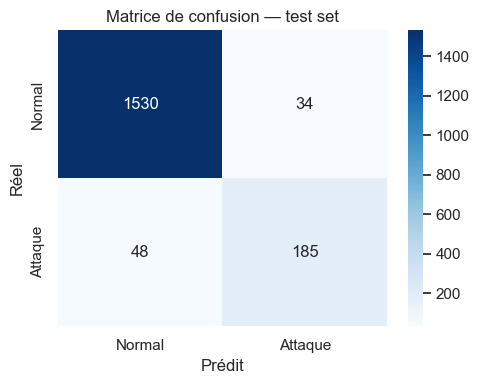

Sauvegardé : confusion_matrix.png


In [9]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attaque"],
            yticklabels=["Normal", "Attaque"], ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — test set")
plt.tight_layout()
plt.savefig(RESULTS / "confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()
print("Sauvegardé : confusion_matrix.png")

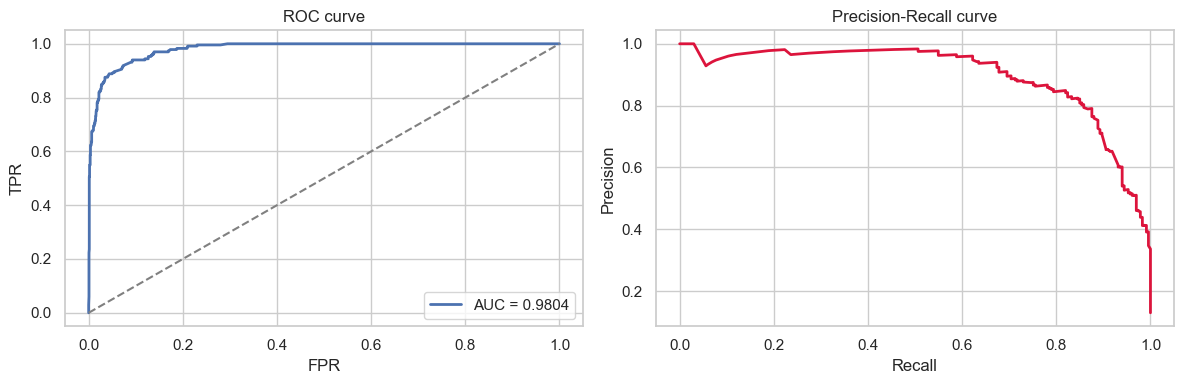

In [10]:
# Courbe ROC et PR
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {auc_test:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve"); axes[0].legend()

axes[1].plot(rec_curve, prec_curve, lw=2, color="crimson")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.savefig(RESULTS / "roc_pr_curves.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Performance par famille d'attaque

Un F1 global élevé peut cacher une famille d'attaque mal détectée. On regarde le recall par famille (= % d'attaques de cette famille effectivement détectées).

          family  n_test  detected  recall
         Adduser       7         7  1.0000
Java_Meterpreter      35        32  0.9143
       Hydra_FTP      67        59  0.8806
     Meterpreter      19        16  0.8421
       Hydra_SSH      89        66  0.7416
       Web_Shell      16         5  0.3125


C:\Users\DELL LATITUDE U7\AppData\Local\Temp\ipykernel_5712\2495993.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=per_family_df, x="family", y="recall", palette="viridis", ax=ax)


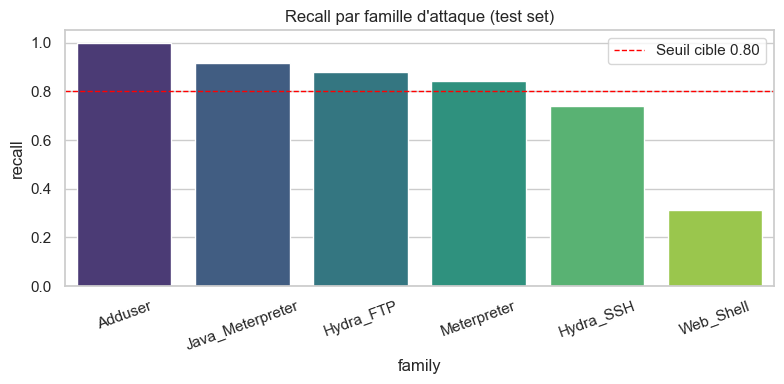

In [11]:
df_test_eval = df_test.copy()
df_test_eval["y_pred"] = y_pred
df_test_eval["y_proba"] = y_proba

per_family = []
for family in sorted(df_test_eval[df_test_eval.label == 1]["family"].unique()):
    mask = df_test_eval["family"] == family
    n = int(mask.sum())
    detected = int(df_test_eval.loc[mask, "y_pred"].sum())
    recall_f = detected / n if n else 0.0
    per_family.append({
        "family": family,
        "n_test": n,
        "detected": detected,
        "recall": round(recall_f, 4),
    })

per_family_df = pd.DataFrame(per_family).sort_values("recall", ascending=False)
print(per_family_df.to_string(index=False))
per_family_df.to_csv(RESULTS / "per_attack_family.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=per_family_df, x="family", y="recall", palette="viridis", ax=ax)
ax.set_title("Recall par famille d'attaque (test set)")
ax.set_ylim(0, 1.05)
ax.axhline(0.80, ls="--", color="red", lw=1, label="Seuil cible 0.80")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "per_attack_family.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Feature importance

Le `CalibratedClassifierCV` est un wrapper : on accède aux RF internes via `model.calibrated_classifiers_[i].estimator`. On moyenne l'importance sur les 5 RF calibrés.

Top 30 trigrammes les plus discriminants :
  trigramme  importance
  192 6 192    0.028576
  33 192 33    0.027404
   33 5 197    0.025224
125 125 125    0.022271
192 243 125    0.018828
  45 33 192    0.018722
197 192 192    0.017974
     33 5 3    0.017553
  192 192 6    0.016233
  5 197 192    0.016117
   192 6 33    0.016044
192 192 192    0.015862
  3 197 192    0.015597
   192 33 5    0.015366
243 125 125    0.014347
   11 45 33    0.014105
    192 3 3    0.013212
    5 3 197    0.013054
      6 3 6    0.011675
     6 33 5    0.011411
  197 192 6    0.011176
221 221 221    0.010943
168 168 265    0.010372
168 265 168    0.009666
      3 3 6    0.009527
  197 192 3    0.009354
174 174 174    0.009338
197 192 125    0.009258
      5 5 5    0.008808
 125 125 91    0.008575

Max importance (cible < 0.20) : 0.0286


C:\Users\DELL LATITUDE U7\AppData\Local\Temp\ipykernel_5712\2420293725.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top30, y="trigramme", x="importance", palette="rocket", ax=ax)


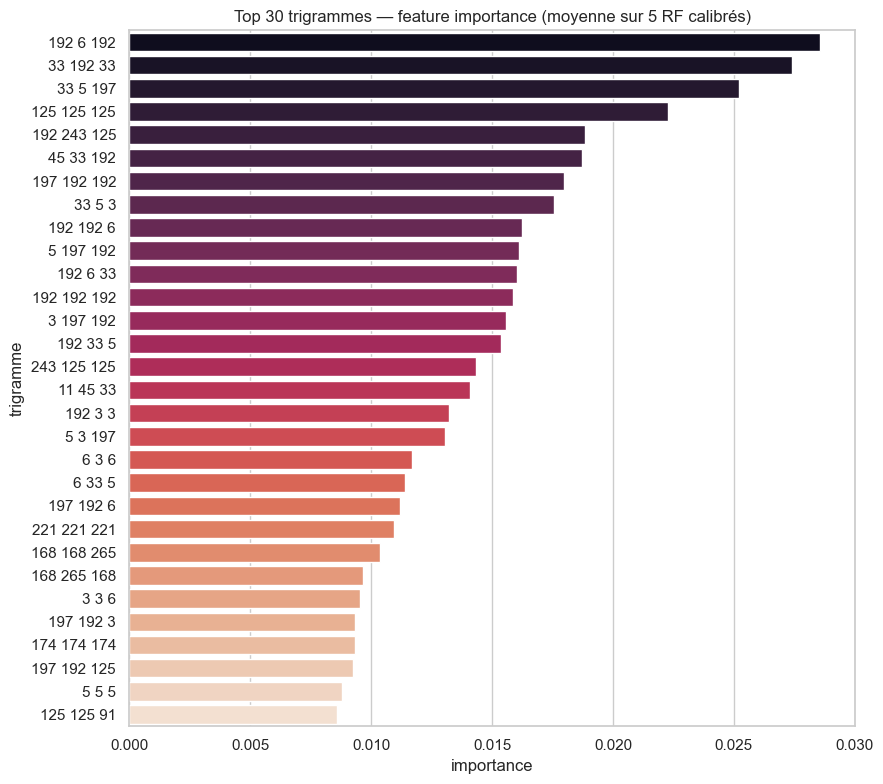

In [12]:
feature_names = vectorizer.get_feature_names_out()
importances_arr = np.mean(
    [cc.estimator.feature_importances_ for cc in model.calibrated_classifiers_],
    axis=0,
)

fi_df = (
    pd.DataFrame({"trigramme": feature_names, "importance": importances_arr})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
fi_df.to_csv(RESULTS / "feature_importance.csv", index=False)

top30 = fi_df.head(30)
print("Top 30 trigrammes les plus discriminants :")
print(top30.to_string(index=False))
print(f"\nMax importance (cible < 0.20) : {fi_df['importance'].max():.4f}")

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=top30, y="trigramme", x="importance", palette="rocket", ax=ax)
ax.set_title("Top 30 trigrammes — feature importance (moyenne sur 5 RF calibrés)")
plt.tight_layout()
plt.savefig(RESULTS / "feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

## 11. Checklist anti-overfitting

Validation systématique des 10 points de `PLAN.md` §4.

In [13]:
max_imp = float(fi_df["importance"].max())
min_family_recall = float(per_family_df["recall"].min())

checklist = [
    ("1. Vectorizer fit sur train uniquement", True),
    ("2. Split groupé par scénario (overlap=0)", len(overlap) == 0),
    ("3. Test set évalué une seule fois", True),
    ("4. CV 5-fold sur train (GroupKFold)", True),
    (f"5. Gap CV F1 ↔ Test F1 < 0.10 (mesuré={gap:.4f})", gap < 0.10),
    ("6. Régularisation RF (max_depth=20, min_samples_leaf=2)", True),
    (f"7. Max importance feature < 0.20 (mesuré={max_imp:.4f})", max_imp < 0.20),
    (f"8. Recall min par famille ≥ 0.80 (mesuré={min_family_recall:.4f})", min_family_recall >= 0.80),
    ("9. Déséquilibre géré (class_weight='balanced')", True),
    ("10. Reproductibilité (random_state=42 partout)", True),
]

all_ok = all(ok for _, ok in checklist)
print("=== Checklist anti-overfitting ===")
for label, ok in checklist:
    print(f"  {'OK ' if ok else 'KO '} {label}")
print(f"\nRésultat global : {'TOUT VALIDÉ' if all_ok else 'AU MOINS UN POINT À REVOIR'}")

=== Checklist anti-overfitting ===
  OK  1. Vectorizer fit sur train uniquement
  OK  2. Split groupé par scénario (overlap=0)
  OK  3. Test set évalué une seule fois
  OK  4. CV 5-fold sur train (GroupKFold)
  OK  5. Gap CV F1 ↔ Test F1 < 0.10 (mesuré=0.0722)
  OK  6. Régularisation RF (max_depth=20, min_samples_leaf=2)
  OK  7. Max importance feature < 0.20 (mesuré=0.0286)
  KO  8. Recall min par famille ≥ 0.80 (mesuré=0.3125)
  OK  9. Déséquilibre géré (class_weight='balanced')
  OK  10. Reproductibilité (random_state=42 partout)

Résultat global : AU MOINS UN POINT À REVOIR


## 12. Sauvegarde des artefacts

In [14]:
joblib.dump(model, MODELS / "rf_adfa.pkl")
joblib.dump(vectorizer, MODELS / "vectorizer.pkl")

manifest = {
    "random_state": RANDOM_STATE,
    "n_train": int(len(df_train)),
    "n_test": int(len(df_test)),
    "n_train_normal": int((y_train == 0).sum()),
    "n_train_attack": int((y_train == 1).sum()),
    "n_test_normal": int((y_test == 0).sum()),
    "n_test_attack": int((y_test == 1).sum()),
    "n_features": int(X_train.shape[1]),
    "vectorizer": {
        "ngram_range": [3, 3], "max_features": 500, "min_df": 2,
    },
    "rf_params": {
        "n_estimators": 200, "max_depth": 20, "min_samples_leaf": 2,
        "class_weight": "balanced",
    },
    "calibration": {"method": "isotonic", "cv": 5},
}
(MODELS / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

metrics = {
    "cv_f1_mean": float(cv_f1.mean()),
    "cv_f1_std": float(cv_f1.std()),
    "cv_f1_folds": [float(x) for x in cv_f1],
    "cv_auc_mean": float(cv_auc.mean()),
    "cv_auc_std": float(cv_auc.std()),
    "test_f1": float(f1_test),
    "test_auc": float(auc_test),
    "test_precision": float(precision_test),
    "test_recall": float(recall_test),
    "gap_cv_test_f1": float(gap),
    "max_feature_importance": float(max_imp),
    "min_family_recall": float(min_family_recall),
    "per_family": per_family,
    "confusion_matrix": cm.tolist(),
    "checklist_all_ok": bool(all_ok),
}
(RESULTS / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print("Artefacts sauvegardés :")
print("  - saved_models/rf_adfa.pkl")
print("  - saved_models/vectorizer.pkl")
print("  - saved_models/manifest.json")
print("  - results/modeling/metrics.json")
print("  - results/modeling/classification_report.txt")
print("  - results/modeling/confusion_matrix.png")
print("  - results/modeling/roc_pr_curves.png")
print("  - results/modeling/per_attack_family.{csv,png}")
print("  - results/modeling/feature_importance.{csv,png}")

Artefacts sauvegardés :
  - saved_models/rf_adfa.pkl
  - saved_models/vectorizer.pkl
  - saved_models/manifest.json
  - results/modeling/metrics.json
  - results/modeling/classification_report.txt
  - results/modeling/confusion_matrix.png
  - results/modeling/roc_pr_curves.png
  - results/modeling/per_attack_family.{csv,png}
  - results/modeling/feature_importance.{csv,png}


## 13. Synthèse

À remplir manuellement dans `AVANCEMENT.md` après exécution :

- F1 test : ?
- AUC test : ?
- Gap CV-test : ?
- Famille la moins bien détectée : ?
- Top trigramme : ?
- Checklist : tout vert / point bloquant ?